In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import pearsonr
import warnings
warnings.filterwarnings('ignore')

In [2]:
from google.colab import files
uploaded=files.upload()

Saving Financial Sample.xlsx to Financial Sample.xlsx


In [3]:
import pandas as pd
df=pd.read_excel("Financial Sample.xlsx")
df.head()

,Segment,Country,Product,Discount Band,Units Sold,Manufacturing Price,Sale Price,Gross Sales,Discounts,Sales,COGS,Profit,Date,Month Number,Month Name,Year
0,Government,Canada,Carretera,NaN,1618.5,3,20,32370.0,0.0,32370.0,16185.0,16185.0,2014-01-01,1,January,2014
1,Government,Germany,Carretera,NaN,1321.0,3,20,26420.0,0.0,26420.0,13210.0,13210.0,2014-01-01,1,January,2014
2,Midmarket,France,Carretera,NaN,2178.0,3,15,32670.0,0.0,32670.0,21780.0,10890.0,2014-06-01,6,June,2014
3,Midmarket,Germany,Carretera,NaN,888.0,3,15,13320.0,0.0,13320.0,8880.0,4440.0,2014-06-01,6,June,2014
4,Midmarket,Mexico,Carretera,NaN,2470.0,3,15,37050.0,0.0,37050.0,24700.0,12350.0,2014-06-01,6,June,2014


In [4]:
print("Number of rows:",df.shape[0])
print("Number of columns:",df.shape[1])
print("\nColumn names:")
print(df.columns.tolist())

Number of rows: 700
Number of columns: 16

Column names:
['Segment', 'Country', 'Product', 'Discount Band', 'Units Sold', 'Manufacturing Price', 'Sale Price', 'Gross Sales', 'Discounts', ' Sales', 'COGS', 'Profit', 'Date', 'Month Number', 'Month Name', 'Year']


In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 700 entries, 0 to 699
Data columns (total 16 columns):
 #   Column               Non-Null Count  Dtype         
---  ------               --------------  -----         
 0   Segment              700 non-null    object        
 1   Country              700 non-null    object        
 2   Product              700 non-null    object        
 3   Discount Band        647 non-null    object        
 4   Units Sold           700 non-null    float64       
 5   Manufacturing Price  700 non-null    int64         
 6   Sale Price           700 non-null    int64         
 7   Gross Sales          700 non-null    float64       
 8   Discounts            700 non-null    float64       
 9    Sales               700 non-null    float64       
 10  COGS                 700 non-null    float64       
 11  Profit               700 non-null    float64       
 12  Date                 700 non-null    datetime64[ns]
 13  Month Number         700 non-null  

In [6]:
df.isnull().sum()

,0
Segment,0
Country,0
Product,0
Discount Band,53
Units Sold,0
Manufacturing Price,0
Sale Price,0
Gross Sales,0
Discounts,0
Sales,0


In [7]:
df["Discount Band"] = df["Discount Band"].fillna("Unknown")

In [8]:
df.isnull().sum()

,0
Segment,0
Country,0
Product,0
Discount Band,0
Units Sold,0
Manufacturing Price,0
Sale Price,0
Gross Sales,0
Discounts,0
Sales,0


In [9]:
print("Number of duplicate rows:",df.duplicated().sum())

Number of duplicate rows: 0


In [10]:
df.describe()

,Units Sold,Manufacturing Price,Sale Price,Gross Sales,Discounts,Sales,COGS,Profit,Date,Month Number,Year
count,700.000000,700.000000,700.000000,7.000000e+02,700.000000,7.000000e+02,700.000000,700.000000,700,700.000000,700.000000
mean,1608.294286,96.477143,118.428571,1.827594e+05,13150.354629,1.696091e+05,145475.211429,24133.860371,2014-04-28 21:36:00,7.900000,2013.750000
min,200.000000,3.000000,7.000000,1.799000e+03,0.000000,1.655080e+03,918.000000,-40617.500000,2013-09-01 00:00:00,1.000000,2013.000000
25%,905.000000,5.000000,12.000000,1.739175e+04,800.320000,1.592800e+04,7490.000000,2805.960000,2013-12-24 06:00:00,5.750000,2013.750000
50%,1542.500000,10.000000,20.000000,3.798000e+04,2585.250000,3.554020e+04,22506.250000,9242.200000,2014-05-16 12:00:00,9.000000,2014.000000
75%,2229.125000,250.000000,300.000000,2.790250e+05,15956.343750,2.610775e+05,245607.500000,22662.000000,2014-09-08 12:00:00,10.250000,2014.000000
max,4492.500000,260.000000,350.000000,1.207500e+06,149677.500000,1.159200e+06,950625.000000,262200.000000,2014-12-01 00:00:00,12.000000,2014.000000
std,867.427859,108.602612,136.775515,2.542623e+05,22962.928775,2.367263e+05,203865.506118,42760.626563,NaN,3.377321,0.433322


In [11]:
df.columns= df.columns.str.strip()
print(df.columns.tolist())

['Segment', 'Country', 'Product', 'Discount Band', 'Units Sold', 'Manufacturing Price', 'Sale Price', 'Gross Sales', 'Discounts', 'Sales', 'COGS', 'Profit', 'Date', 'Month Number', 'Month Name', 'Year']


In [12]:
print("Total Sales:",df["Sales"].sum())
print("Average Sales:",df["Sales"].mean())

print("Total Profit:",df["Profit"].sum())
print("Average Profit:",df["Profit"].mean())

print("Total Units Sold:",df["Units Sold"].sum())
print("Average Units Sold:",df["Units Sold"].mean())






Total Sales: 118726350.25999999
Average Sales: 169609.07179999998
Total Profit: 16893702.259999998
Average Profit: 24133.860371428567
Total Units Sold: 1125806.0
Average Units Sold: 1608.2942857142857


In [13]:
print("Sales column exists:","Sales"in df.columns)

Sales column exists: True


In [14]:

print("Total Sales:",df["Sales"].sum())
print("Average Sales:",df["Sales"].mean())

print("Total Profit:",df["Profit"].sum())
print("Average Profit:",df["Profit"].mean())

print("Total Units Sold:",df["Units Sold"].sum())
print("Average Units Sold:",df["Units Sold"].mean())


Total Sales: 118726350.25999999
Average Sales: 169609.07179999998
Total Profit: 16893702.259999998
Average Profit: 24133.860371428567
Total Units Sold: 1125806.0
Average Units Sold: 1608.2942857142857


In [15]:
product_sales = df.groupby("Product")["Sales"].sum().sort_values(ascending=False)

print(product_sales)

Product
Paseo        3.301114e+07
VTT          2.051192e+07
Velo         1.825006e+07
Amarilla     1.774712e+07
Montana      1.539080e+07
Carretera    1.381531e+07
Name: Sales, dtype: float64


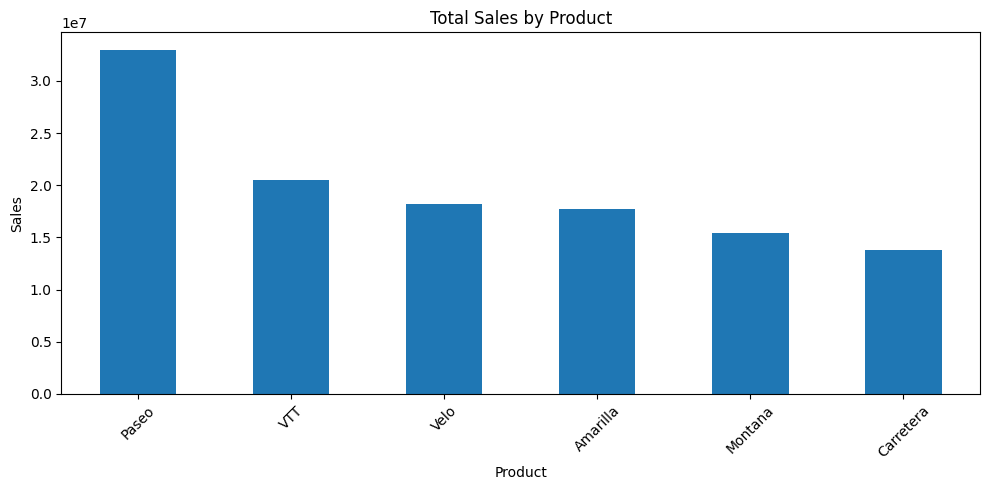

In [16]:
product_sales.plot(kind="bar",figsize=(10,5))
plt.title("Total Sales by Product")
plt.xlabel("Product")
plt.ylabel("Sales")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

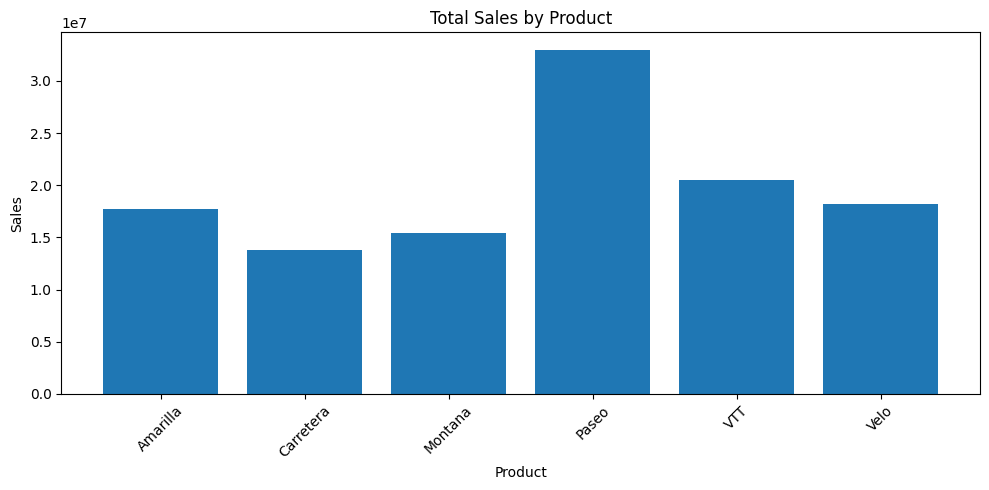

In [17]:
# create sales by prduct
product_sales=df.groupby("Product")["Sales"].sum()

plt.figure(figsize=(10, 5))
plt.bar(product_sales.index, product_sales.values)

plt.title("Total Sales by Product")
plt.xlabel("Product")
plt.ylabel("Sales")
plt.xticks(rotation=45)

plt.tight_layout()
plt.show()

Product
Paseo        4797437.950
VTT          3034608.020
Amarilla     2814104.060
Velo         2305992.465
Montana      2114754.880
Carretera    1826804.885
Name: Profit, dtype: float64


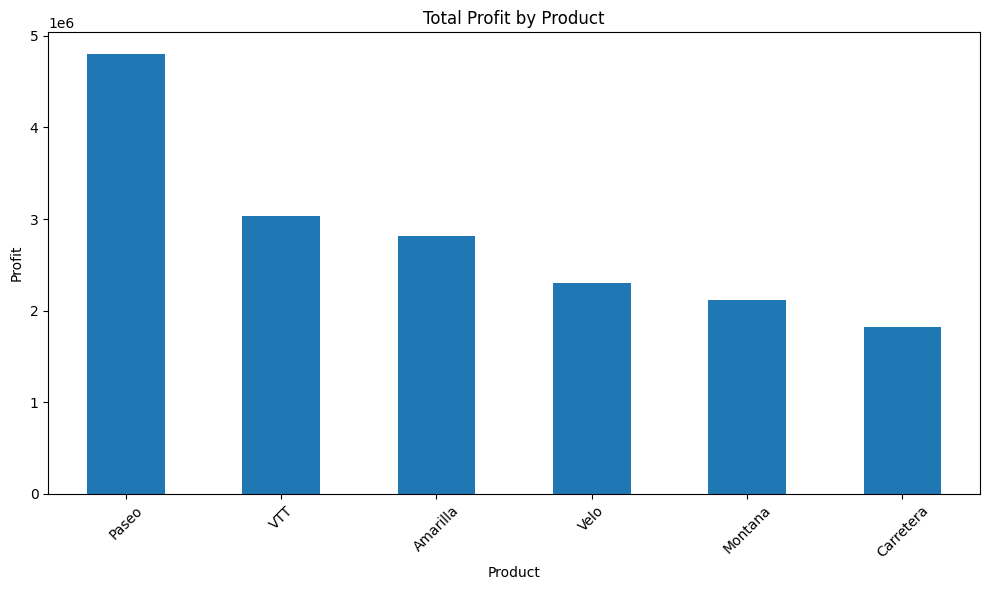

In [18]:
# Total Profit by product
product_profit=df.groupby("Product")["Profit"].sum().sort_values(ascending=False)

print(product_profit)

plt.figure(figsize=(10, 6))
product_profit.plot(kind="bar")

plt.title("Total Profit by Product")
plt.xlabel("Product")
plt.ylabel("Profit")
plt.xticks(rotation=45)

plt.tight_layout()
plt.show()

Country
United States of America    2.502983e+07
Canada                      2.488765e+07
France                      2.435417e+07
Germany                     2.350534e+07
Mexico                      2.094935e+07
Name: Sales, dtype: float64


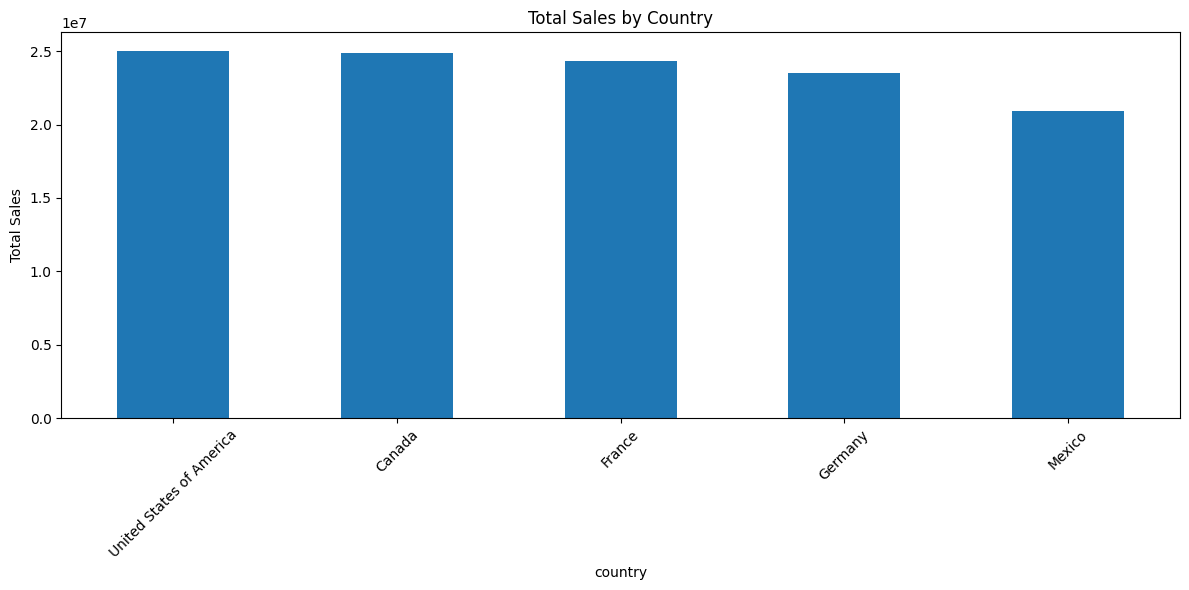

In [19]:
#Total Sales by Country
country_sales= df.groupby("Country")["Sales"].sum().sort_values(ascending=False)

print(country_sales)

plt.figure(figsize=(12,6))
country_sales.plot(kind="bar")

plt.title("Total Sales by Country")
plt.xlabel("country")
plt.ylabel("Total Sales")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()



Country
France                      3781020.780
Germany                     3680388.820
Canada                      3529228.885
United States of America    2995540.665
Mexico                      2907523.110
Name: Profit, dtype: float64


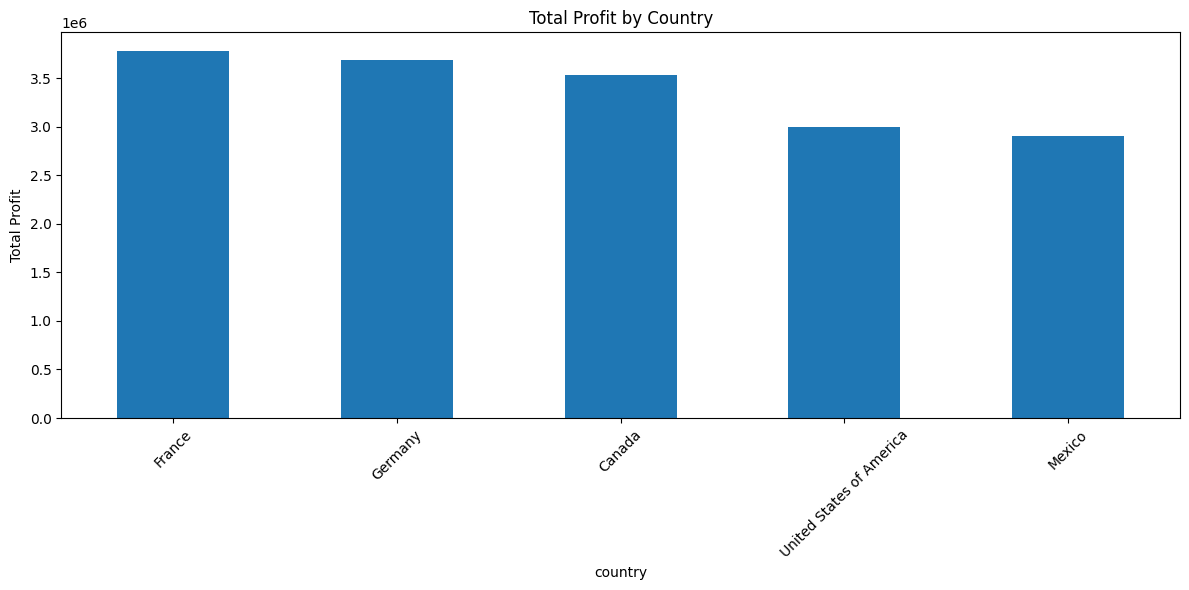

In [20]:
#Total Profit by Country
country_profit= df.groupby("Country")["Profit"].sum().sort_values(ascending=False)

print(country_profit)

plt.figure(figsize=(12,6))
country_profit.plot(kind="bar")

plt.title("Total Profit by Country")
plt.xlabel("country")
plt.ylabel("Total Profit")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()


Year
2013    26415255.51
2014    92311094.75
Name: Sales, dtype: float64


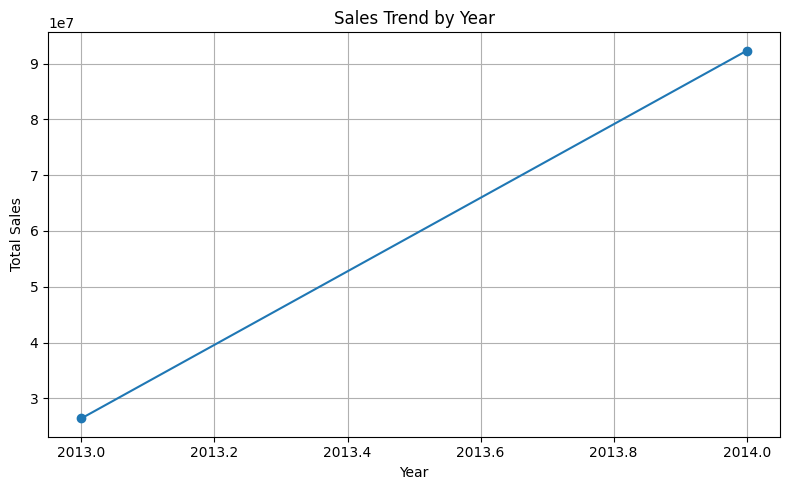

In [21]:
#Sales Trend Over Time
yearly_sales= df.groupby("Year")["Sales"].sum()

print(yearly_sales)

plt.figure(figsize=(8,5))
yearly_sales.plot(kind="line",marker="o")

plt.title("Sales Trend by Year")
plt.xlabel("Year")
plt.ylabel("Total Sales")
plt.grid(True)
plt.tight_layout()
plt.show()


Month Name
April         6964775.07
August        5864622.42
December     17367228.98
February      7297531.39
January       6607761.68
July          8102920.18
June          9518893.82
March         5586859.87
May           6210211.06
November     12651417.50
October      21671431.02
September    10882697.27
Name: Sales, dtype: float64


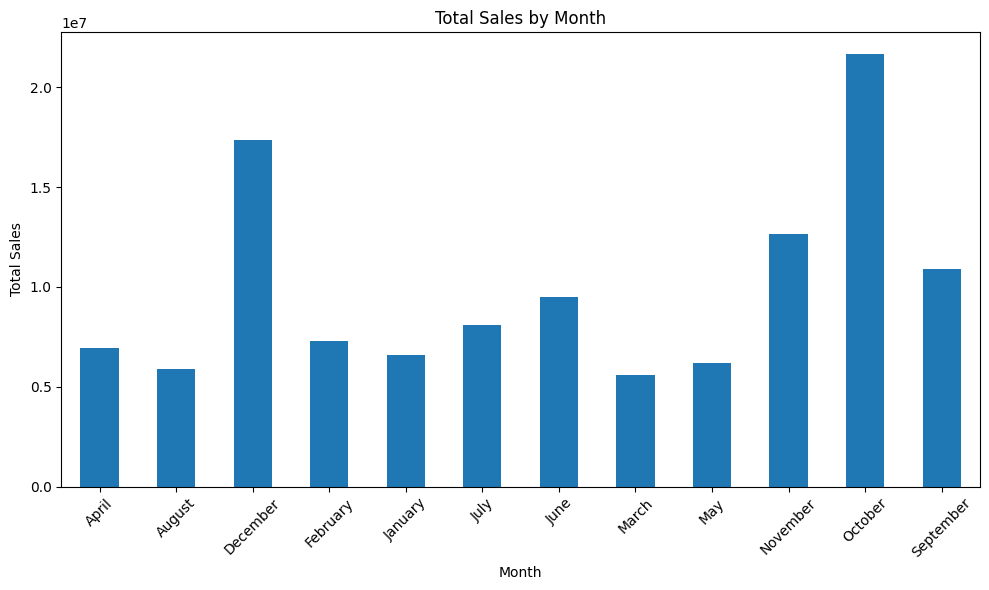

In [22]:
#Monthly Sales Analysis
#Total Sales by Country
monthly_sales= df.groupby("Month Name")["Sales"].sum()

print(monthly_sales)

plt.figure(figsize=(10,6))
monthly_sales.plot(kind="bar")

plt.title("Total Sales by Month")
plt.xlabel("Month")
plt.ylabel("Total Sales")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()


In [23]:
#Correlation Analysis
numeric_df= df.select_dtypes(include="number")
correlation=numeric_df.corr()
print(correlation)

                     Units Sold  Manufacturing Price    Sale Price  \
Units Sold             1.000000            -0.029644 -6.506581e-02   
Manufacturing Price   -0.029644             1.000000  7.078637e-02   
Sale Price            -0.065066             0.070786  1.000000e+00   
Gross Sales            0.327221             0.049852  8.082502e-01   
Discounts              0.253048             0.020578  6.416890e-01   
Sales                  0.326914             0.051549  8.058777e-01   
COGS                   0.331694             0.046857  7.993354e-01   
Profit                 0.228437             0.061985  6.504947e-01   
Month Number          -0.103607             0.005021  5.122894e-17   
Year                   0.063857            -0.000927 -4.211383e-15   

                     Gross Sales  Discounts     Sales      COGS    Profit  \
Units Sold              0.327221   0.253048  0.326914  0.331694  0.228437   
Manufacturing Price     0.049852   0.020578  0.051549  0.046857  0.061985  

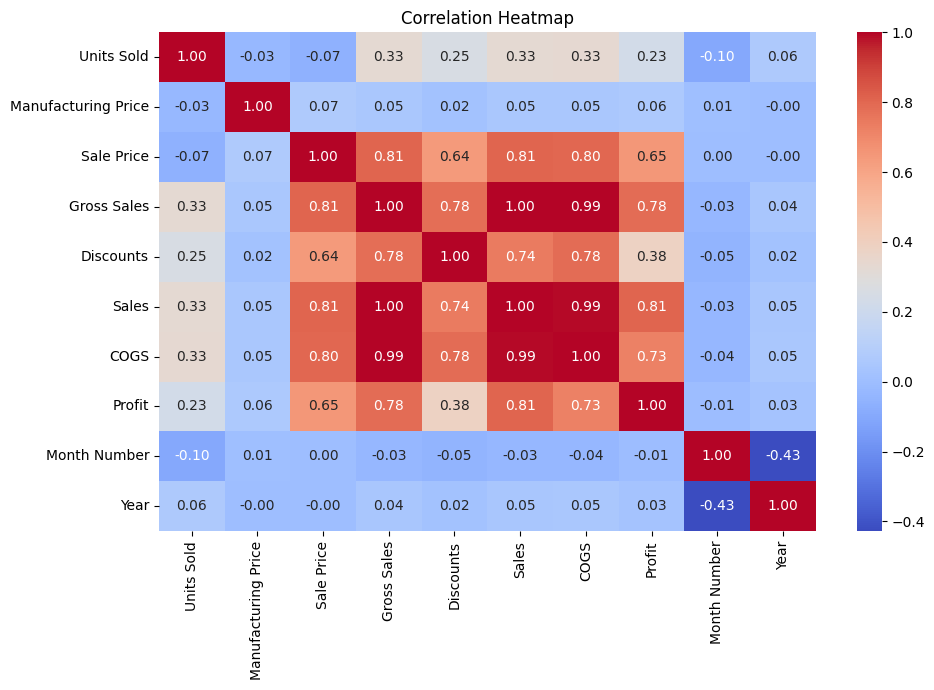

In [24]:
#Correlation Heatmap
plt.figure(figsize=(10, 7))

sns.heatmap(correlation,annot=True,fmt=".2f",cmap="coolwarm")
plt.title("Correlation Heatmap")
plt.tight_layout()
plt.show()

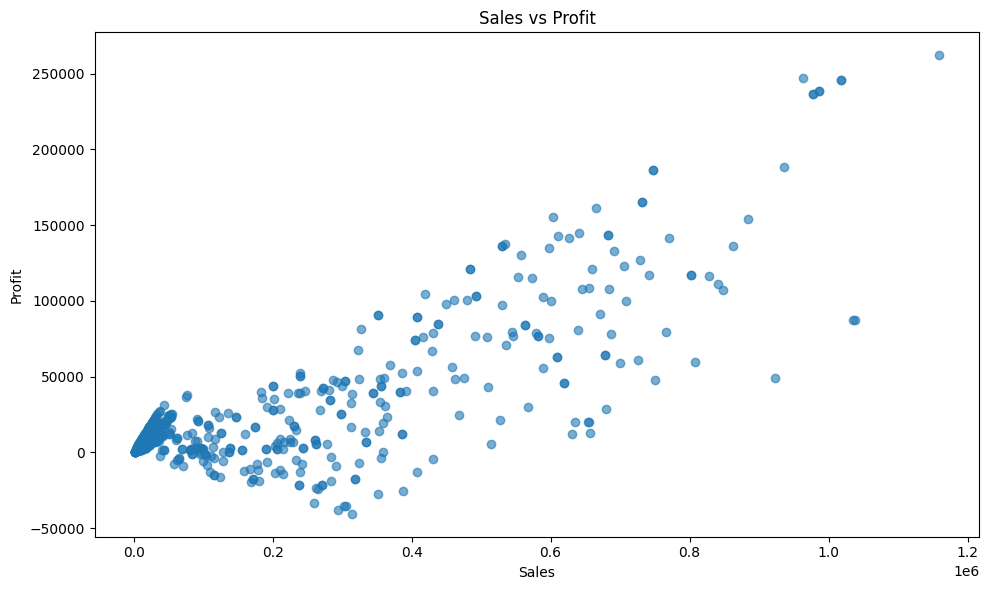

In [25]:
#Sales vs Profit Scatter Plot
plt.figure(figsize=(10,6))

plt.scatter(df["Sales"],df["Profit"],alpha=0.6)
plt.xlabel("Sales")
plt.ylabel("Profit")
plt.title("Sales vs Profit")

plt.tight_layout()
plt.show()

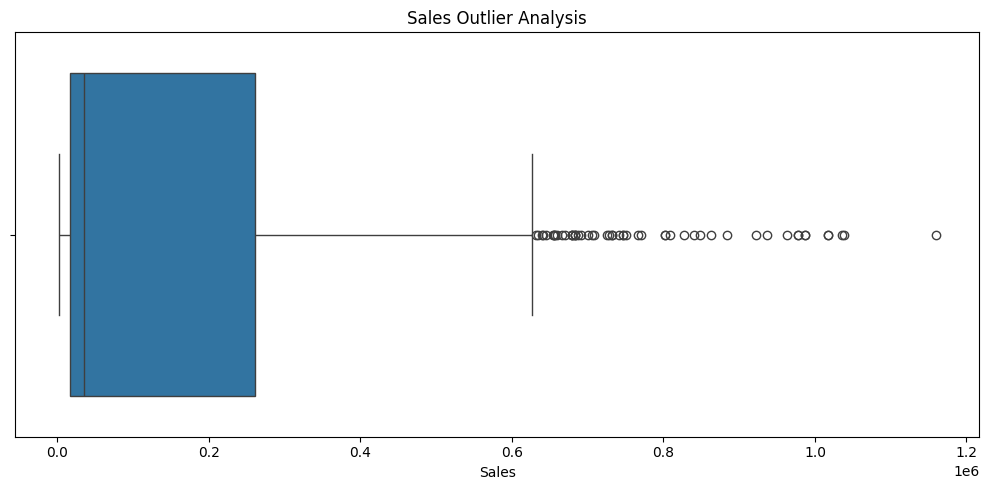

In [26]:
#Sales Outlier Analysis
plt.figure(figsize=(10,5))

sns.boxplot(x=df["Sales"])

plt.title("Sales Outlier Analysis")
plt.xlabel("Sales")

plt.tight_layout()
plt.show()


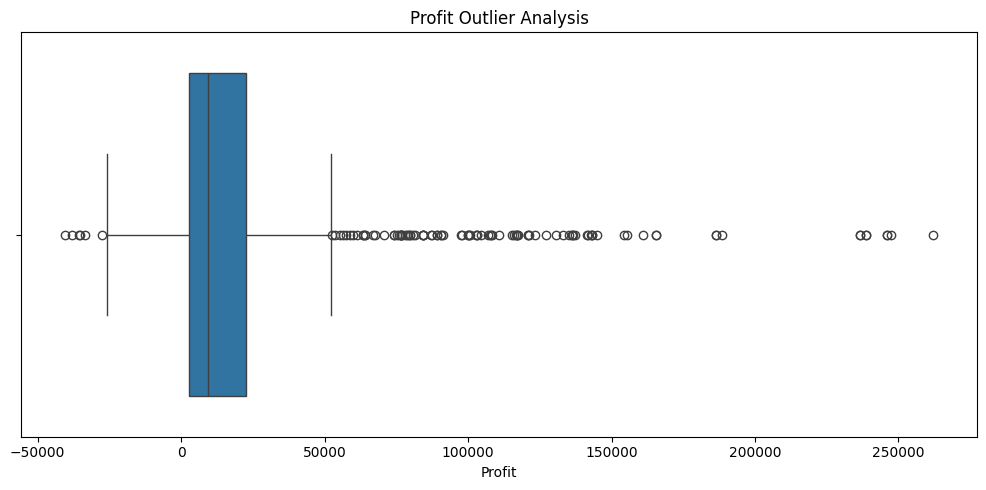

In [27]:
#Profit Outlier Analysis
plt.figure(figsize=(10,5))

sns.boxplot(x=df["Profit"])

plt.title("Profit Outlier Analysis")
plt.xlabel("Profit")

plt.tight_layout()
plt.show()

In [28]:
#Hypothesis Testing:Sales vs Profit
from scipy.stats import pearsonr

correlation_value, p_value=pearsonr(df["Sales"],df["Profit"])
print("Correlation_value",correlation_value)
print("P-value:", p_value)

Correlation_value 0.8054621941564629
P-value: 9.665586768429874e-161


In [29]:
print(df.columns.tolist())

['Segment', 'Country', 'Product', 'Discount Band', 'Units Sold', 'Manufacturing Price', 'Sale Price', 'Gross Sales', 'Discounts', 'Sales', 'COGS', 'Profit', 'Date', 'Month Number', 'Month Name', 'Year']


In [30]:
#Key Findings
print("KEY FINDINGS")
print("-" * 50)

print("\nTotal Sales:",round(df["Sales"].sum(),2))
print("Average Sales:",round(df["Sales"].mean(),2))

print("\nTotal Profit:",round(df["Profit"].sum(),2))
print("Average Profit:",round(df["Profit"].mean(),2))

print("\nTotal Units Sold:",int(df["Units Sold"].sum()))
print("Average Units Sold:",round(df["Units Sold"].mean(),2))

product_sales=df.groupby("Product")["Sales"].sum()
product_profit=df.groupby("Product")["Profit"].sum()

print("\nTop Product by Sales:")
print(product_sales.idxmax())

print("\nTop Product by Profit:")
print(product_profit.idxmax())


country_sales=df.groupby("Country")["Sales"].sum()
country_profit=df.groupby("Country")["Profit"].sum()

print("\nTop Country by Sales:")
print(country_sales.idxmax())


print("\nTop Country by Profit:")
print(country_profit.idxmax())



KEY FINDINGS
--------------------------------------------------

Total Sales: 118726350.26
Average Sales: 169609.07

Total Profit: 16893702.26
Average Profit: 24133.86

Total Units Sold: 1125806
Average Units Sold: 1608.29

Top Product by Sales:
Paseo

Top Product by Profit:
Paseo

Top Country by Sales:
United States of America

Top Country by Profit:
France


In [31]:
#Final Data Quality Check
print("Missing values after cleaning:")
print(df.isnull().sum())

print("\nTotal missing values:")
print(df.isnull().sum().sum())

print("\nDuplicate rows:")
print(df.duplicated().sum())

print("\nDataset shape:")
print(df.shape)

Missing values after cleaning:
Segment                0
Country                0
Product                0
Discount Band          0
Units Sold             0
Manufacturing Price    0
Sale Price             0
Gross Sales            0
Discounts              0
Sales                  0
COGS                   0
Profit                 0
Date                   0
Month Number           0
Month Name             0
Year                   0
dtype: int64

Total missing values:
0

Duplicate rows:
0

Dataset shape:
(700, 16)


In [32]:
#Final EDA Summary

print("=" * 60)
print("FINAL EDA SUMMARY")
print("=" * 60)

print("\n1.DATASET")
print("Rows:",df.shape[0])
print("Columns:",df.shape[1])

print("\n2.SALES")
print("Total Sales:",round(df["Sales"].sum(),2))
print("Average Sales:",round(df["Sales"].mean(),2))

print("\n3.PROFIT")
print("Total Profit:",round(df["Profit"].sum(),2))
print("Average Profit:",round(df["Profit"].mean(),2))

print("\n4.UNITS SOLD")
print("Total Units Sold:",int(df["Units Sold"].sum()))
print("Average Units Sold:",round(df["Units Sold"].mean(),2))

print("\n5.TOP PRODUCT BY SALES")
print(df.groupby("Product")["Sales"].sum().idxmax())

print("\n6.TOP PRODUCT BY PROFIT")
print(df.groupby("Product")["Profit"].sum().idxmax())

print("\n7.TOP COUNTRY BY SALES")
print(df.groupby("Country")["Sales"].sum().idxmax())

print("\n8.TOP COUNTRY BY PROFIT")
print(df.groupby("Country")["Profit"].sum().idxmax())

print("\n9.DATA QUALITY")
print("Total Missing Values:",df.isnull().sum().sum())
print("Duplicate Rows:",df.duplicated().sum())

print("=" * 60)








FINAL EDA SUMMARY

1.DATASET
Rows: 700
Columns: 16

2.SALES
Total Sales: 118726350.26
Average Sales: 169609.07

3.PROFIT
Total Profit: 16893702.26
Average Profit: 24133.86

4.UNITS SOLD
Total Units Sold: 1125806
Average Units Sold: 1608.29

5.TOP PRODUCT BY SALES
Paseo

6.TOP PRODUCT BY PROFIT
Paseo

7.TOP COUNTRY BY SALES
United States of America

8.TOP COUNTRY BY PROFIT
France

9.DATA QUALITY
Total Missing Values: 0
Duplicate Rows: 0


Conclusion

Exploratory Data Analysis was performed on the Financial Sample dataset to understand sales performance, profitability, product performance, country-wise performance, and sales trends.

The dataset was examined for its structure, data types, missing values, and duplicate records.Missing values in the Discount Band column were handled, and duplicate records were checked.

Sales and profit were analyzed by product and country, while yearly and monthly sales trends were examined to identify patterns.Correlation analysis, scatter plots, and boxplots were used to study relationships and potential outliers.
Pearson correlation testing was also performed to examine the relationship between Sales and Profit.

Overall,the analysis provided useful insights into business performance and demonstrated the use of Python,Pandas,Matplotlib,Seaborn,and statistical analysis techniques for exploratory data analysis.